# Information
## Source
This notebook prepares the data from Lawley et al. (2022) using the version from https://drive.google.com/file/d/1jyxbPmwhMEhgezxMTxwmKTuU1PhT9yPe using the original H3 hexagonal polygon data.

**Citaton**: <p>
Christopher J.M. Lawley, Anne E. McCafferty, Garth E. Graham, David L. Huston, Karen D. Kelley, Karol Czarnota, Suzanne Paradis, Jan M. Peter, Nathan Hayward, Mike Barlow, Poul Emsbo, Joshua Coyan, Carma A. San Juan, Michael G. Gadd: <br>
Data–driven prospectivity modelling of sediment–hosted Zn–Pb mineral systems and their critical raw materials. <br>
Ore Geology Reviews, Volume 141, 2022, 104635, ISSN 0169-1368, https://doi.org/10.1016/j.oregeorev.2021.104635.

## How to
1. Get the datacube from the link above and extract the .csv file. In this notebook, we use *data/LAWLEY22/RAW*.<p> If you intially copied the data into the src/data folder, you're already done.
2. Read the *Model setup* section<p>
3. Choose the baseline model from the Lawley et al. (2022) paper. Since we're working with the MVT, the definition is based on the **baseline** MVT model from the paper. <br>Your'e welcome to add other models in the <code>model.py</code> as you want to. The notebook will consider all **keys** with a **True** value, but not those with a **False** one. This way, it's easy to change exports as desired.<p>
4. Make some **user-defined** decisions and adjust path names etc. if necessary. <p>**ALL** possible user-interactions are in uppercase-letters.<br>The only point not considered here are the **Training** columns which may need some change if you want to export data for a **CD** model. You can do so down below in the **ground truth** investigation cells. Simply change *Training_MVT* to *Training_CD* if necessary.<p>
**We have to mention, that the generation of proxies like distance calculations, first and second order derivatives etc. will not work correctly with a geopgraphic CRS**.

## Important
This notebook is designed to work with the **datacube** from Lawley et al. (2022). I.e., it does **not** use the **rasterized** data from the preprocessing examples.<p>
All of the **datacube** models are marked by "**DC**" in the model name.

## Model setup

Note that the **Geology_Dictionary** categories contain more than the incorporated dictionaries. Lawley et al. (2022) explicitly stated that:
- Sedimentary dictionaries = FineClastic, Carbonaceous, Calcareous
- Igneous dictionaries = Felsic, Intermediate, Mafic, Ultramafic
- Metamorphic dictionaries = Anatectic, Gneissose, Schistose

However, the complete list would be like:
- Sedimentary dictionaries = FineClastic, Carbonaceous, Calcareous, **Cherty, CoarseClastic, Evaporitic, RedBed, Sedimentary**
- Igneous dictionaries = Felsic, Intermediate, Mafic, Ultramafic, **Alkalic, Pegmatitic**
- Metamorphic dictionaries = Anatectic, Gneissose, Schistose

Also note, that the **Mafic** dictionary **does not exist** as separate column in the datacube and thus was not considered in the model setup!<br>
However, it seems to be included in the <i>Geology_Dictionary_UltramaficMafic</i> dict.

In [1]:
# Custom modules
import beak.experimental.utilities.io as io

In [2]:
import beak.experimental.utilities.eda as eda
from beak.experimental.utilities import conversions
from beak.models import mvt_nat                   # Includes the model definitions used in this notebook 


In [3]:
# Standard libraries
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers

from collections import Counter

import os
from pathlib import Path

import sys
if sys.version_info < (3, 9):
    from importlib_resources import files
else:
    from importlib.resources import files

# Insert the path to the root directory of the project
sys.path.insert(0, str(Path(os.getcwd()).parent.parent))

BASE_PATH = files("beak.data")

# Definitions
**User inputs**

In [4]:
# Choose model
MODEL = "MVT_BASELINE"

# Path to datacube and export folder
PATH_DATACUBE_IN = BASE_PATH / "LAWLEY22" / "RAW" / "2021_Table04_Datacube.csv"
PATH_DATA_OUT = BASE_PATH

PATH_ML_MODELS = "models/"
PATH_MODEL_RESULTS = "exports/"
PATH_TRAIN_LOGS = "logs/"

FORMAT = "FEATHER"                                  # FEATHER, CSV

# ROI
REGIONS =["United States of America", "Canada"]     # Canada, United States of America, Australia
N_ROWS = None                                       # Number of rows to read from datacube, None for all

COL_GROUND_TRUTH_MAX = "Training_MVT"
COLS_GROUND_TRUTH_DATACUBE = ["Training_MVT_Deposit", "Training_MVT_Occurrence"]
COLS_GROUND_TRUTH = [COL_GROUND_TRUTH_MAX] + COLS_GROUND_TRUTH_DATACUBE

FILTER_COL = "Longitude_EPSG4326"
FILTER_VAL = 0

ground_truth_selected = COL_GROUND_TRUTH_MAX


In [5]:
# Path variables
datacube = Path(PATH_DATACUBE_IN)
feather = Path(os.path.join(os.path.dirname(PATH_DATACUBE_IN), os.path.basename(PATH_DATACUBE_IN).split(".")[0] + ".feather"))

export_folder = io.check_path(Path(PATH_DATA_OUT))
model_folder = io.check_path(Path(PATH_ML_MODELS))
model_log_folder = io.check_path(Path(PATH_TRAIN_LOGS))
model_results_folder = io.check_path(Path(PATH_MODEL_RESULTS))

# Relevant columns for choosen model (considering only True values)
model = mvt_nat.models[MODEL]
model_columns = [key for key, value in model.items() if value == True]

# Allow only 3 decimals in DataFrame view
pd.options.display.float_format = "{:.3f}".format

# Set column to filter by region
region_column = "Country_Majority"
selected_columns = COLS_GROUND_TRUTH_DATACUBE + model_columns + [region_column]
filter_column = FILTER_COL

# Show selected evicence layers
for i, layer in enumerate(model_columns):
  print(f"Evidence layer {i+1}/{len(model_columns)}: {layer}")

# Random state
seed = 42  

# Scaler
scaler_type = "standard"

Evidence layer 1/12: Gravity_GOCE_ShapeIndex
Evidence layer 2/12: Gravity_Bouguer
Evidence layer 3/12: Gravity_Bouguer_HGM
Evidence layer 4/12: Gravity_Bouguer_UpCont30km_HGM
Evidence layer 5/12: Gravity_Bouguer_HGM_Worms_Proximity
Evidence layer 6/12: Gravity_Bouguer_UpCont30km_HGM_Worms_Proximity
Evidence layer 7/12: Magnetic_HGM
Evidence layer 8/12: Magnetic_LongWavelength_HGM
Evidence layer 9/12: Magnetic_HGM_Worms_Proximity
Evidence layer 10/12: Magnetic_LongWavelength_HGM_Worms_Proximity
Evidence layer 11/12: Seismic_LAB_Hoggard
Evidence layer 12/12: Seismic_Moho


# 0: Functions

**Unsorted**

In [6]:


def get_timestamp():
    return datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

Data **preparation**

In [7]:
from sklearn.impute import SimpleImputer

def impute_data(data, columns):
  data_imputed = data.copy()
  imputer = SimpleImputer(strategy="mean", missing_values=np.nan)
  data_imputed[columns] = imputer.fit_transform(data_imputed[columns])
  
  return data_imputed


In [8]:
def create_train_test_splits(X, y, test_size=0.2, seed=seed, out_dtype=np.float32, out_type="tensorflow"):
  """Create training and testing data"""
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)
  
  if out_type == "tensorflow":
    X_train = tf.convert_to_tensor(X_train, dtype=out_dtype)
    X_test = tf.convert_to_tensor(X_test, dtype=out_dtype)
    y_train = tf.convert_to_tensor(y_train, dtype=np.int8)
    y_test = tf.convert_to_tensor(y_test, dtype=np.int8)
  elif out_type == "numpy":
    X_train = X_train.astype(out_dtype)
    X_test = X_test.astype(out_dtype)
    y_train = y_train.astype(np.int8)
    y_test = y_test.astype(np.int8)
    
  return X_train, X_test, y_train, y_test

In [9]:
from imblearn.over_sampling import RandomOverSampler

def oversample_data(X, y, sampling_strategy=0.5, random_state=seed, shrinkage=0.0):
  ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=seed, shrinkage=shrinkage)
  X_ros, y_ros = ros.fit_resample(X, y)
  print(f"Resampled dataset shape {Counter(y_ros)}, positive/negative ratio: {round(Counter(y_ros)[1] / Counter(y_ros)[0], 2)}")
  
  return X_ros.astype(np.float32), y_ros.astype(np.int8)


In [10]:
def create_subsets(X, y, num_downsampling, ground_truth=ground_truth_selected, seed=seed):
  Xy = pd.concat([X, y], axis=1)
  Xy_subset = Xy.sample(n=num_downsampling, random_state=seed)

  X_subset = Xy_subset.drop(columns=[ground_truth], inplace=False)
  y_subset = Xy_subset[ground_truth]
  print(f"Subset dataset shape {Counter(y_subset)}")

  return X_subset, y_subset


def select_random_samples(X, y, sampling_strategy=0.1, sampling_class="negatives", seed=seed):
  X_positives = X[y == 1] 
  X_negatives = X[y == 0]

  X_samples = X_negatives if sampling_class == "negatives" else X_positives
  X_samples = X_samples.sample(frac=sampling_strategy, random_state=seed, replace=False)

  X_positives = X_samples if sampling_class == "positives" else X_positives
  X_negatives = X_samples if sampling_class == "negatives" else X_negatives
  
  X_samples = pd.concat([X_positives, X_negatives], axis=0)
  y_samples = np.concatenate([np.ones(X_positives.shape[0]), np.zeros(X_negatives.shape[0])])

  print(f"Subset dataset shape {Counter(y_samples)}")
  return X_samples, y_samples


In [11]:
def create_number_of_random_negatives(X, y, multiplier=20, decimals=3):
  y_positives = y[y == 1]
  random_num_negatives = len(y_positives) * multiplier
  ratio = round(random_num_negatives / len(X), decimals)
  return ratio


#### **Building** and **training** ANN models

In [12]:
from tensorflow import keras

def save_ml_model(model, model_name, path=PATH_ML_MODELS):
  """Saves model to disk"""
  model.save(path + model_name + ".keras")
  

def load_ml_model(model_name, path=PATH_ML_MODELS):
  """Loads model from disk"""
  return keras.models.load_ml_model(path + model_name + ".keras")

In [13]:


def tensorboard_callback(folder, model_name):
  log_dir = os.path.join(folder, model_name + "_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
  
  training_log = tf.keras.callbacks.TensorBoard(log_dir=log_dir)
  print(f"Saving TensorBoard log files to: {log_dir}")
  return training_log

In [14]:
def train_ann(X, 
              y,
              model,
              validation_data=None, 
              validation_split=0.2,  
              validation_steps=None,
              epochs=100, 
              batch_size=32, 
              optimizer=tf.keras.optimizers.Adam, 
              loss=tf.keras.losses.binary_crossentropy, 
              metrics=[tf.keras.metrics.BinaryAccuracy()], 
              callbacks=[], 
              verbose=0,
              seed=42,
              mixed_precision=False):
  """Train ANN model"""
  # Set mixed precision policy
  if mixed_precision is True:
    tf.keras.mixed_precision.set_global_policy(policy='mixed_float16')
  else:
    tf.keras.mixed_precision.set_global_policy(policy='float32')

  tf.random.set_seed(seed)  

  # Print settings
  print(f"Random seed: {seed}, precision: {tf.keras.mixed_precision.global_policy().name}\n")
  
  if validation_data:
    print(f"Training on {X.shape[0]} samples.\n")
  else:
    print(f"Training on {int(X.shape[0] - X.shape[0] * validation_split)} samples.\n")
    
  model.compile(optimizer=optimizer(learning_rate=0.001), loss=loss, metrics=metrics)
  return model.fit(X, y, validation_data=validation_data, validation_split=validation_split, validation_steps=validation_steps, epochs=epochs, batch_size=batch_size, callbacks=callbacks, verbose=verbose)
    

In [15]:
# Simple initial ANN model
def create_simple_ann(num_features, model_name="ANN", hidden_units=1, activation=tf.keras.activations.relu, batch_norm=False, seed=42):
  """Create a new ANN model"""  
  tf.random.set_seed(seed)
  neurons = num_features*2 + 1

  input = tf.keras.Input(shape=(num_features,), name="Input_layer")
  x = layers.Dense(neurons, activation=activation, name="Hidden_layer_1")(input)
  x = layers.BatchNormalization()(x) if batch_norm is True else x
  
  if hidden_units > 1:
    for i in range(1, hidden_units):
      hidden_unit_name = f"Hidden_layer_{i+1}"
      x = layers.Dense(neurons, activation=activation, name=hidden_unit_name)(x)
      x = layers.BatchNormalization()(x) if batch_norm is True else x  
       
  output = layers.Dense(1, activation=tf.keras.activations.sigmoid, dtype=tf.float32, name="Output_layer")(x)
  return tf.keras.Model(inputs=input, outputs=output, name=model_name)


In [16]:
# Simple initial ANN model
def create_simple_ann(num_features, model_name="ANN", hidden_units=1, activation=tf.keras.activations.relu, batch_norm=False, seed=42):
  """Create a new ANN model"""  
  tf.random.set_seed(seed)
  neurons = num_features*2 + 1

  input = tf.keras.Input(shape=(num_features,), name="Input_layer")
  x = layers.Dense(neurons, activation=activation, name="Hidden_layer_1")(input)
  x = layers.BatchNormalization()(x) if batch_norm is True else x
  
  if hidden_units > 1:
    for i in range(1, hidden_units):
      hidden_unit_name = f"Hidden_layer_{i+1}"
      x = layers.Dense(neurons, activation=activation, name=hidden_unit_name)(x)
      x = layers.BatchNormalization()(x) if batch_norm is True else x  
       
  output = layers.Dense(1, activation=tf.keras.activations.sigmoid, dtype=tf.float32, name="Output_layer")(x)
  return tf.keras.Model(inputs=input, outputs=output, name=model_name)
  

In [17]:
# Create complex ANN models
def create_ann_c1(num_features, model_name="ANN", min_exp=6, hidden_units=1, activation=tf.keras.activations.relu, batch_norm=False, seed=42):
  """Create a new ANN model"""  
  tf.random.set_seed(seed)

  neurons = 2**min_exp
  input = tf.keras.Input(shape=(num_features,), name="Input_layer")
  x = layers.Dense(2**min_exp, activation=activation, name="Hidden_layer_1")(input)
  x = layers.BatchNormalization()(x) if batch_norm is True else x
  
  if hidden_units > 1:
    for i in range(1, hidden_units):
      neurons = 2**(min_exp + i)
      hidden_unit_name = f"Hidden_layer_{i+1}"
      x = layers.Dense(neurons, activation=activation, name=hidden_unit_name)(x)
      x = layers.BatchNormalization()(x) if batch_norm is True else x  
       
  output = layers.Dense(1, activation=tf.keras.activations.sigmoid, name="Output_layer")(x)
  return tf.keras.Model(inputs=input, outputs=output, name=model_name)
  

## **Evaluation**

Plot loss curve

In [18]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
  
def plot_loss(history):
  plt.plot(history.history['loss'], label='Training Loss')
  plt.plot(history.history['val_loss'], label='Validation Loss')
  plt.title('Loss Function')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.show();


Get ROC/AUC measures

In [19]:
def eval_roc_auc(model, X, y, plot=True, batch_size=1024):
  """Evaluate ROC AUC score"""
  # ROC AUC score
  y_pred = model.predict(X, verbose=0, batch_size=batch_size)
  eval_roc_auc = roc_auc_score(y, y_pred)
  
  # ROC curve
  if plot is True:
    fpr, tpr, _ = roc_curve(y, y_pred)
    
    # Plotting
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (area = {eval_roc_auc:.4})")
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
  else:
    print(f"ROC AUC score: {eval_roc_auc:.4}")
    
  return eval_roc_auc


Plot loss and ROC curves

In [20]:
def plot_loss_and_roc(history, model, X, y, batch_size=1024):
  """Plot loss and ROC curve
  
  Example usage:
  Assuming 'history' is the training history and 'model' is your trained model
  Replace X and y with your actual data and call  plot_loss_and_roc(history, model, X, y)
  
  """
  plt.figure(figsize=(12, 5))

  plt.subplot(1, 2, 1)
  plt.plot(history.history['loss'], label='Training Loss')
  plt.plot(history.history['val_loss'], label='Validation Loss')
  plt.title('Loss Function')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()

  # Evaluate ROC AUC and plot ROC curve
  plt.subplot(1, 2, 2)
  y_pred = model.predict(X, verbose=0, batch_size=batch_size)
  fpr, tpr, _ = roc_curve(y, y_pred)
  roc_auc = auc(fpr, tpr)

  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (area = {roc_auc:.4})")
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('Receiver Operating Characteristic')
  plt.legend(loc="lower right")

  plt.tight_layout(pad=3) 
  plt.show()


Calculate metrics

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def eval_metrics(model, X, y, batch_size=2048, only_positives=False):
  if only_positives is True:
    X = X[y == 1]
    y = y[y == 1]

  y_pred =  model.predict(X, batch_size=batch_size, verbose=0)
  y_pred = y_pred.reshape(y.shape)
  y_pred = np.round(y_pred, 0).astype(np.int8)

  accuracy = accuracy_score(y, y_pred)
  precision = precision_score(y, y_pred)
  recall = recall_score(y, y_pred)
  f1score = f1_score(y, y_pred)

  if only_positives is False:
    print(f"Test on positive and negative labels ({len(y[y==1])}/{len(y[y==0])}):\nAccuracy: {accuracy:.4}, Precision: {precision:.4}, Recall: {recall:.4}, F1 Score: {f1score:.4}\n")
  else:
    print(f"Test on positive labels only ({len(y[y==1])}):\nAccuracy: {accuracy:.4}, Precision: {precision:.4}, Recall: {recall:.4}, F1 Score: {f1score:.4}\n")


**Create** callbacks

In [22]:
import datetime

def tensorboard_callback(folder, model_name, timestamp=True):
  if timestamp is True:
    log_dir = os.path.join(folder, model_name + "_" + get_timestamp())
  else:
    log_dir = os.path.join(folder, model_name)
  
  training_log = tf.keras.callbacks.TensorBoard(log_dir=log_dir)
  print(f"Saving TensorBoard log files to: {log_dir}")
  return training_log


#### **Create** training data 

In [23]:
def create_train_test_splits(X, y, test_size=0.2, seed=seed, out_dtype=tf.float32):
  """Create training and testing data"""
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)
  
  X_train = tf.convert_to_tensor(X_train, dtype=out_dtype)
  X_test = tf.convert_to_tensor(X_test, dtype=out_dtype)
  y_train = tf.convert_to_tensor(y_train, dtype=np.int8)
  y_test = tf.convert_to_tensor(y_test, dtype=np.int8)
  
  return X_train, X_test, y_train, y_test

#### **Prediction** tools


In [24]:
def set_nodata(data, prediction, columns):
  out_nodata = -9999.
  
  nan_mask = np.isnan(data[columns]).to_numpy()
  nan_mask = np.max(nan_mask, axis=1)
  nan_mask = nan_mask.reshape(-1, 1)
  
  return np.where(nan_mask, out_nodata, prediction)  


def predict_values(data, model_columns, model, batch_size=512, verbose=1, impute=True,  setback_nodata=False):
  assert not (impute and setback_nodata), "Imputing and setting back nodata is not possible at the same time!"
    
  if impute is True and setback_nodata is False:
    data = impute_data(data, columns=model_columns)

  prediction = model.predict(data[model_columns], batch_size=batch_size, verbose=verbose)
  
  if setback_nodata is True and impute is False:
    out_data = set_nodata(data, prediction, columns=model_columns) if impute is False else prediction
  else:
    out_data = prediction
    
  return out_data
  

#### **Export** tools

In [25]:
def export_prediction(data=feather, region_column=region_column, out_name=None, prediction=None, out_path=PATH_MODEL_RESULTS, filter_column=filter_column, filter_value=FILTER_VAL):
  """Exports prediction to raster"""  
  # Load initial data to get coordinates
  print("Loading data...")
  if len(filter_column) > 0 and filter_value is not None:
    data = io.load_feather(feather, columns=["H3_Geometry", region_column, filter_column])
    data = data[data[filter_column] < filter_value]
    data.drop(columns=[filter_column], inplace=True)
  else:
    data = io.load_feather(feather, columns=["H3_Geometry", region_column])
    
  data = data[data[region_column].isin(REGIONS)]
  
  print("Converting prediction...")
  data[out_name] = prediction.squeeze()

  print("Creating geodataframe...")
  gdf = data[["H3_Geometry", out_name]].copy()
  gdf = conversions.create_geodataframe_from_polygons(data=gdf, polygon_col="H3_Geometry", epsg_code=4326)

  # Create and export rasters
  print("Exporting raster...\n")
  _, _ , _ = conversions.rasterize_vector(value_type="numerical",
                                          value_columns=[out_name],
                                          geodataframe=gdf,
                                          nodata_value=-9999.0,
                                          resolution=0.025,
                                          epsg_code=4326,
                                          dtype=np.float32,
                                          raster_save=True,
                                          raster_save_folder=out_path)

# 1: **Create** file list

In [26]:
# Not needed since we're working with the original datacube dataset


# 2-7: Data Preparation

## **Load** data from csv or feather

In [27]:
# Convert to feather format if chosen
if FORMAT == "CSV" and datacube.exists():
  print("Loading datacube...")
  df = io.load_dataset(datacube, nrows=N_ROWS)
elif FORMAT == "FEATHER" and feather.exists():
    print("Loading feather...")
    df = io.load_feather(feather, columns=selected_columns)
elif not datacube.exists() and not feather.exists():
  print("Data not found!")
  
# Filter loaded data and initial NaN data preparation
print("Filtering data...")
df = df[df[region_column].isin(REGIONS)]
df.drop(columns=[region_column], inplace=True)
df.replace("-", np.nan, inplace=True)

# Create combined (max) column for training points 
print("Creating combined training column...")
df.insert(len(COLS_GROUND_TRUTH_DATACUBE), COL_GROUND_TRUTH_MAX, df.apply(lambda row: "Present" if "Present" in [row["Training_MVT_Deposit"], row["Training_MVT_Occurrence"]] else "Absent", axis=1))

# Output dataframe
print(f"\nData rows: {df.shape[0]}, data columns: {df.shape[1]}")

Loading feather...
Filtering data...


Creating combined training column...

Data rows: 3620129, data columns: 15


In [28]:
# Show loaded dataframe
df

,Training_MVT_Deposit,Training_MVT_Occurrence,Training_MVT,Gravity_GOCE_ShapeIndex,Gravity_Bouguer,Gravity_Bouguer_HGM,Gravity_Bouguer_UpCont30km_HGM,Gravity_Bouguer_HGM_Worms_Proximity,Gravity_Bouguer_UpCont30km_HGM_Worms_Proximity,Magnetic_HGM,Magnetic_LongWavelength_HGM,Magnetic_HGM_Worms_Proximity,Magnetic_LongWavelength_HGM_Worms_Proximity,Seismic_LAB_Hoggard,Seismic_Moho
0,Absent,Absent,Absent,0.081,-89.514,0.000,0.000,1.780,2.132,0.000,0.000,2.881,0.937,187.994,42.602
1,Absent,Absent,Absent,0.081,-90.153,0.000,0.000,0.870,1.860,0.000,0.000,1.141,0.740,187.929,42.602
2,Absent,Absent,Absent,0.081,-89.506,0.000,0.000,1.791,1.858,0.000,0.000,3.276,1.145,187.948,42.602
3,Absent,Absent,Absent,0.080,-89.094,0.000,0.000,2.553,1.512,0.000,0.000,4.745,1.862,187.994,42.602
4,Absent,Absent,Absent,0.074,-88.918,0.000,0.000,1.319,2.579,0.000,0.000,4.590,1.794,187.994,42.602
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3620124,Absent,Absent,Absent,0.801,-92.152,0.001,0.000,0.337,15.400,0.000,0.000,5.161,17.636,159.195,48.248
3620125,Absent,Absent,Absent,0.801,-90.493,0.001,0.000,1.238,16.384,0.000,0.000,4.198,18.668,159.195,48.132
3620126,Absent,Absent,Absent,0.802,-89.583,0.001,0.000,2.430,16.941,0.000,0.000,2.560,19.667,159.189,47.174
3620127,Absent,Absent,Absent,0.801,-94.609,0.001,0.000,1.328,15.227,0.000,0.000,2.526,17.695,159.207,48.248


## **Prepare** training data

There are only few rows with NaN values within the **positive** ground truth data. These will be dropped for both the following analysis and training.<p>

For **inference**, NaN values will be imputed with an appropriate method to maintain the shape of the input data. <br>After inference, rows containing
 NaN values can be masked or replaced with a NoData value for raster export.

 Commonly, normalization of data is done after **train** and **test** split creation. However, to keep things simple and stay conform with the advangeo workflow for comparison, the normalization is done right before creating the actual model input and test data. This means, that the prediction and training data are not completely intependent of each other, since they are still related to the statistics used for normalization. Therefore, test metrics may be bit better and the model may be less generalized than the other way.

### Get numerical columns

In [29]:
# Get "real" numerical columns in advance
model_columns_numerical = df.select_dtypes(include=np.number).columns.tolist()


## **Encode** categorical columns

### Ground truth

In [30]:
# Encode the ground truth column
df[ground_truth_selected] = df[ground_truth_selected].map({"Present": 1, "Absent": 0})


## **Remove** outliers

In [31]:
df_outliers = df[[ground_truth_selected] + model_columns_numerical].copy()
df_no_outliers = eda.clip_outliers(df_outliers, model_columns_numerical)
df_no_outliers_copy = df_no_outliers.copy()


## **Normalize** data


In [32]:
def normalize_data(data, data_columns, method=scaler_type):
  data_scaled = data.copy()

  if method == "standard":
    scaler = StandardScaler()
  elif method == "minmax":
    scaler = MinMaxScaler()
    
  data_scaled[data_columns] = scaler.fit_transform(data_scaled[data_columns])
  return data_scaled, scaler

In [33]:
print(f"Scaler-type: {scaler_type}")
df_model, scaler = normalize_data(df_no_outliers, model_columns_numerical)
df_model_copy = df_model.copy()

Scaler-type: standard


## **Drop** NaN data

Dropping of NaN values could also be moved to the beginning or before the scaling. However, this way, data are the same when predicting on them and do not need to be scaled before inference. The advangeo workflow is basically predicting on all values, even the negatives, which were used in training (i.e., unknowns are treated as negatives and not as unknown). That's not the usual ML-way and may have some drawbacks, but to keep things comparable, we´re going with this setup, at least for the inital ann tests.

In [34]:
# Drop rows with NaN values
df_model.dropna(how="any", inplace=True)

print(f"Data rows for all values: {df_model.shape[0]}, data columns: {df_model.shape[1]}")

num_negatives = df_model[df_model[ground_truth_selected] == 0].shape[0]
print("\nData rows for Absent values:", num_negatives)

num_positives = df_model[df_model[ground_truth_selected] == 1].shape[0]
print("Data rows for Present values:", num_positives)


Data rows for all values: 3449989, data columns: 13

Data rows for Absent values: 3448149
Data rows for Present values: 1840


## **Balance** and **subset** data

In [35]:
X = df_model.drop(columns=[ground_truth_selected], inplace=False)
y = df_model[ground_truth_selected]

## **Impute** and **subset** data

In [36]:
df_model_imputed = df_model_copy.copy()
df_model_imputed = impute_data(df_model_imputed, model_columns_numerical)

X_imputed = df_model_imputed.drop(columns=[ground_truth_selected], inplace=False)
y_imputed = df_model_imputed[ground_truth_selected]

### **Create** positive/negative subsets

In [37]:
# Create selection of the positives and negatives for testing purposes
X_positives = df_model[df_model[ground_truth_selected] == 1].drop(columns=[ground_truth_selected], inplace=False).astype(np.float32)
y_positives = df_model[df_model[ground_truth_selected] == 1][ground_truth_selected].astype(np.float32)

# 8: **Modeling**

### Approach TTS: **separate** data sets for training and testing
Holding out labels from the avalailable data may result in poor model performance due to the low number of samples **and their spatial distribution**.<br>It is still under discussion how to split data and how to use them for training and testing in a standardized way. However, we recommend the to create a model (CPL or "**production model**") based on all available data (positive labels and sampled negatives).<p>
We actually see calculated metrics more as guides for model performance rather than hard rules due to 
- the highliy imbalanced data
- the low number of available positive labels
- the assumption, that negatives used for training are **true** negatives (in fact, they are supposed to be but could also be positives)
- we do not have **true negatives** yet to incorporate (which most likely will be result in better model performance and more realistic evaluation metrics)


**M2F-I-DC:** Train/test split first, afterwards oversampling with Batch Norm


In [82]:
downsample_ratio = create_number_of_random_negatives(X_imputed, y_imputed, multiplier=20, decimals=5)
print(f"Downsample ratio: {downsample_ratio}")

X_rs, y_rs = select_random_samples(X_imputed, y_imputed, sampling_strategy=downsample_ratio, sampling_class="negatives", seed=seed)
X_train, X_test, y_train, y_test = create_train_test_splits(X_rs, y_rs, test_size=0.2)
X_rs_ros, y_rs_ros = oversample_data(X_train, y_train, sampling_strategy=0.5, random_state=seed, shrinkage=0.0)

print(f"Test dataset shape {Counter(y_test.numpy())}")

X_train = tf.convert_to_tensor(X_rs_ros, dtype=tf.float32)
y_train = tf.convert_to_tensor(y_rs_ros, dtype=tf.int8)

Downsample ratio: 0.01024
Subset dataset shape Counter({0.0: 37051, 1.0: 1854})
Resampled dataset shape Counter({0: 29672, 1: 14836}), positive/negative ratio: 0.5
Test dataset shape Counter({0: 7379, 1: 402})


In [83]:
epochs = 50
batch_size = 512

# Name
model_name = "LAWLEY22_DC_ANN_TTS_M2F_I_C1_SMALL_" + str(epochs) + "_EPOCHS_" + str(batch_size) + "_BATCH_SIZE_" + get_timestamp()

# Model
model = create_ann_c1(num_features=X_train.shape[1], model_name=model_name, min_exp=5, hidden_units=2, activation=tf.keras.activations.relu, batch_norm=True, seed=seed)
model.summary()


Model: "LAWLEY22_DC_ANN_TTS_M2F_I_C1_SMALL_50_EPOCHS_512_BATCH_SIZE_20240412-143845"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Input_layer (InputLayer)    [(None, 12)]              0         
                                                                 
 Hidden_layer_1 (Dense)      (None, 32)                416       
                                                                 
 batch_normalization_7 (Bat  (None, 32)                128       
 chNormalization)                                                
                                                                 
 Hidden_layer_2 (Dense)      (None, 64)                2112      
                                                                 
 batch_normalization_8 (Bat  (None, 64)                256       
 chNormalization)                                                
                                                         

In [84]:
# Callbacks
callbacks = [tensorboard_callback(model_log_folder, model_name)] 

# Training
train_results = train_ann(X_train, y_train, model, validation_split=0.2, epochs=epochs, batch_size=batch_size, callbacks=callbacks, seed=seed, verbose=0)



Saving TensorBoard log files to: logs\LAWLEY22_DC_ANN_TTS_M2F_I_C1_SMALL_50_EPOCHS_512_BATCH_SIZE_20240412-143845_20240412-143852
Random seed: 42, precision: float32

Training on 35606 samples.



In [85]:
# Save model
save_ml_model(model, model_name)


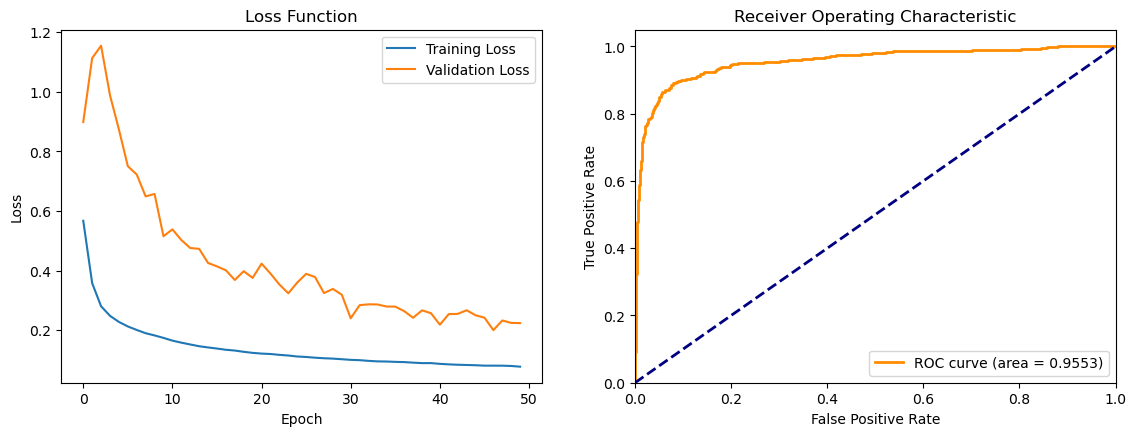

Test on positive and negative labels (402/7379):
Accuracy: 0.9644, Precision: 0.6263, Recall: 0.7711, F1 Score: 0.6912

Test on positive labels only (402):
Accuracy: 0.7711, Precision: 1.0, Recall: 0.7711, F1 Score: 0.8708



In [86]:
# Plot loss and roc curve
plot_loss_and_roc(train_results, model, X_test, y_test, batch_size=512)

# Positive and negative labels
eval_metrics(model, X_test, y_test)

# Only positive labels
eval_metrics(model, X_test, y_test, only_positives=True)

In [87]:
print("Predicting...")
prediction = predict_values(df_model_copy, model_columns_numerical, model, batch_size=512)


Predicting...


7071/7071 [==============================] - 6s 824us/step


In [88]:
print("\nExporting...")
export_prediction(data=feather, region_column=region_column, out_name=model_name, prediction=prediction, filter_value=None)


Exporting...
Loading data...
Converting prediction...
Creating geodataframe...
Exporting raster...

Number of threads rasterizing: 48


Rasterizing: 100%|██████████| 1/1 [06:01<00:00, 361.67s/it]


### Approach CPL: **no** train/test-splitting for training
Testing the model on the downsampled dataset with intial number of mineral occurences ("**production model**").

In [39]:
downsample_ratio = create_number_of_random_negatives(X_imputed, y_imputed, multiplier=20, decimals=5)
print(f"Downsample ratio: {downsample_ratio}")

X_rs, y_rs = select_random_samples(X_imputed, y_imputed, sampling_strategy=downsample_ratio, sampling_class="negatives", seed=seed)
X_rs_ros, y_rs_ros = oversample_data(X_rs, y_rs, sampling_strategy=0.5, random_state=seed, shrinkage=0.0)

X_train = tf.convert_to_tensor(X_rs_ros, dtype=tf.float32)
y_train = tf.convert_to_tensor(y_rs_ros, dtype=tf.int8)

X_test = X_rs
y_test = y_rs

print(f"Training dataset shape {Counter(y_rs_ros)}")
print(f"Test dataset shape {Counter(y_test)}")


Downsample ratio: 0.01024
Subset dataset shape Counter({0.0: 37051, 1.0: 1854})
Resampled dataset shape Counter({0.0: 37051, 1.0: 18525}), positive/negative ratio: 0.5
Training dataset shape Counter({0: 37051, 1: 18525})
Test dataset shape Counter({0.0: 37051, 1.0: 1854})


In [40]:
epochs = 50
batch_size = 512

# Name
model_name = "LAWLEY22_DC_ANN_CPL_M2F_I_C1_SMALL_" + str(epochs) + "_EPOCHS_" + str(batch_size) + "_BATCH_SIZE_" + get_timestamp()

# Model
model = create_ann_c1(num_features=X_train.shape[1], model_name=model_name, min_exp=5, hidden_units=2, activation=tf.keras.activations.relu, batch_norm=True, seed=seed)
model.summary()

# Callbacks
callbacks = [tensorboard_callback(model_log_folder, model_name, timestamp=False)] 


Model: "LAWLEY22_DC_ANN_CPL_M2F_I_C1_SMALL_50_EPOCHS_512_BATCH_SIZE_20240416-150031"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Input_layer (InputLayer)    [(None, 12)]              0         
                                                                 
 Hidden_layer_1 (Dense)      (None, 32)                416       
                                                                 
 batch_normalization (Batch  (None, 32)                128       
 Normalization)                                                  
                                                                 
 Hidden_layer_2 (Dense)      (None, 64)                2112      
                                                                 
 batch_normalization_1 (Bat  (None, 64)                256       
 chNormalization)                                                


                                                                 
 Output_layer (Dense)        (None, 1)                 65        
                                                                 
Total params: 2977 (11.63 KB)
Trainable params: 2785 (10.88 KB)
Non-trainable params: 192 (768.00 Byte)
_________________________________________________________________
Saving TensorBoard log files to: logs\LAWLEY22_DC_ANN_CPL_M2F_I_C1_SMALL_50_EPOCHS_512_BATCH_SIZE_20240416-150031


In [41]:
# Training
train_results = train_ann(X_train, y_train, model, validation_split=0.2, epochs=epochs, batch_size=batch_size, callbacks=callbacks, seed=seed, verbose=0)

# Save model
save_ml_model(model, model_name)

Random seed: 42, precision: float32

Training on 44460 samples.



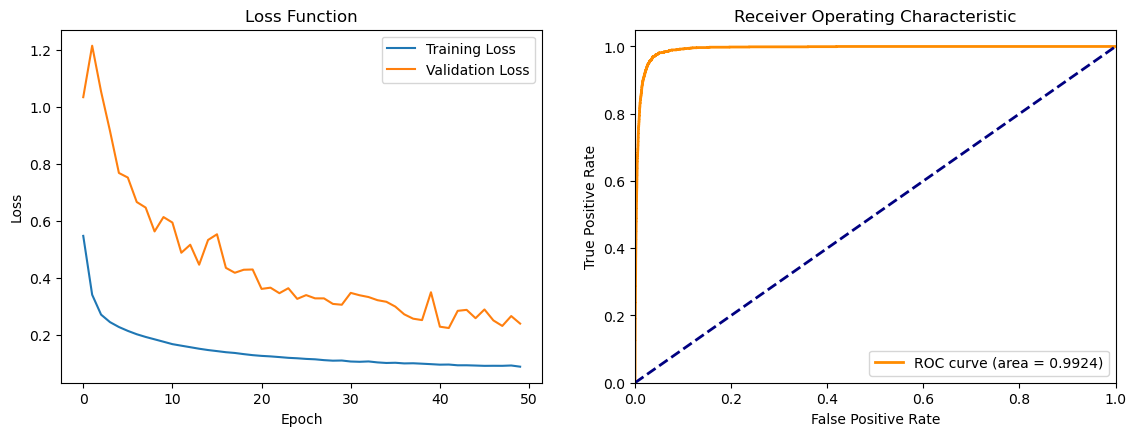

Test on positive and negative labels (1854/37051):
Accuracy: 0.9779, Precision: 0.7083, Recall: 0.9115, F1 Score: 0.7972

Test on positive labels only (1854):
Accuracy: 0.9115, Precision: 1.0, Recall: 0.9115, F1 Score: 0.9537



In [42]:
# Plot loss and roc curve
plot_loss_and_roc(train_results, model, X_test, y_test, batch_size=512)

# Positive and negative labels
eval_metrics(model, X_test, y_test)

# Only positive labels
eval_metrics(model, X_test, y_test, only_positives=True)

In [43]:
print("Predicting...")
prediction = predict_values(df_model_copy, model_columns_numerical, model, batch_size=512)


Predicting...
7071/7071 [==============================] - 5s 743us/step


In [44]:
print("\nExporting...")
export_prediction(data=feather, region_column=region_column, out_name=model_name, prediction=prediction, filter_value=None)


Exporting...
Loading data...
Converting prediction...
Creating geodataframe...
Exporting raster...

Number of threads rasterizing: 48


Rasterizing: 100%|██████████| 1/1 [05:50<00:00, 350.13s/it]


# 9: Evaluate

## Load and evaluate models

Prepare data

In [ ]:
downsample_ratio = create_number_of_random_negatives(X, y, multiplier=20, decimals=5)
print(f"Downsample ratio: {downsample_ratio}")
X_test, y_test = select_random_samples(X, y, sampling_strategy=downsample_ratio, sampling_class="negatives", seed=seed)


Load model

In [ ]:
model_name = "ADD_MODEL_NAME_HERE"

model = load_ml_model(model_name=model_name)
model.summary()

ROC curve and AUC score

In [ ]:
eval_roc_auc(model, X_test, y_test)


Basic evaluation metrics

In [ ]:
eval_metrics(model, X_test, y_test)
eval_metrics(model, X_test, y_test, only_positives=True)
